# Reversion, excess impact, and execution-conditioned decay

This notebook implements the first two roadmap stages:

1. establish transparent short-horizon reversion benchmarks and inspect dense event-response paths;
2. test whether unusually large impact adds predictive information to the reversion rule.

It is deliberately not a profitability backtest. Returns start at a completed event-bar endpoint, but fees, spread, slippage, overlapping positions, and position limits have not yet been applied.

## Definitions

For event bar (t), let (s_t=\operatorname{sign}(Q_t)), where (Q_t) is signed BTC imbalance. The prior return uses the 12,000 events ending before the current bar:

\[
u_t=10^4\log(P_{t-1}/P_{t-k-1}).
\]

The order-flow-aligned pretrend is (z_t=s_tu_t). A high positive (z_t) means the prior trend and current imbalance point in the same direction. Its reversion position is (-s_t).

The fitted impact curve is estimated separately for buys and sells using training observations only:

\[
\widehat I_s(x)=a_s+b_s\log(1+x/q_0),
\qquad
e_t=I_t-\widehat I_{s_t}(x_t).
\]

The excess-impact condition is (e_t) in its side-specific, training-frozen top quintile. No validation or later-sandbox observations enter the fit or cut points.

In [1]:
from pathlib import Path
import math
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
get_ipython().run_line_magic('matplotlib', 'inline')

REPO = Path('/Users/petermillington/Research/market-impact-research')
ALPHA = REPO / 'alpha-search'
EXCESS_ROOT = ALPHA / 'reports' / 'excess_impact_v1'
DECAY_ROOT = ALPHA / 'reports' / 'event_decay_v1'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False, 'axes.spines.right': False})
BUY, SELL = '#13795b', '#c2413b'
PERIOD_COLOURS = {'train': '#64748b', 'validation': '#2563eb', 'later_sandbox': '#d97706'}

## Manual controls

In [2]:
BAR_SIZE = 200                 # 200, 500, or 1_000
HORIZON_MINUTES = 10           # 5, 10, 15, 20, or 30
SIDE = 'sell'                  # 'sell' or 'buy'
DECAY_PERIOD = 'validation'    # 'train', 'validation', or 'later_sandbox'
DECAY_CATEGORY = 'multi_price_all'

assert BAR_SIZE in {200, 500, 1_000}
assert HORIZON_MINUTES in {5, 10, 15, 20, 30}
assert SIDE in {'sell', 'buy'}

## Load compact result tables

In [3]:
impact_fits = pl.read_csv(EXCESS_ROOT / 'impact_fits.csv')
impact_bins = pl.read_csv(EXCESS_ROOT / 'impact_curve_bins.csv')
residual_monthly = pl.read_csv(EXCESS_ROOT / 'residual_monthly.csv')
horizon_accuracy = pl.read_csv(EXCESS_ROOT / 'horizon_accuracy.csv')
quintile_curves = pl.read_csv(EXCESS_ROOT / 'quintile_curves.csv')
conditioning_grid = pl.read_csv(EXCESS_ROOT / 'conditioning_grid.csv')
signal_summary = pl.read_csv(EXCESS_ROOT / 'signal_summary.csv')
incremental = pl.read_csv(EXCESS_ROOT / 'incremental_conditioning.csv')
monthly_signal = pl.read_csv(EXCESS_ROOT / 'monthly_signal_summary.csv')

category_counts = pl.read_csv(DECAY_ROOT / 'event_category_counts.csv')
decay_sample = pl.read_csv(DECAY_ROOT / 'decay_sample_summary.csv')
decay_daily = pl.read_csv(DECAY_ROOT / 'decay_daily.csv').with_columns(
    pl.when(pl.col('source_month') < '2020-09').then(pl.lit('train'))
    .when(pl.col('source_month') < '2021-07').then(pl.lit('validation'))
    .otherwise(pl.lit('later_sandbox')).alias('period')
)

print(f"Decay anchors: {decay_sample['sample_events'].sum():,} from {decay_sample['source_events'].sum():,} events")
display(horizon_accuracy.filter(
    (pl.col('construction') == f'event_{BAR_SIZE}') &
    pl.col('horizon_minutes').is_in([10, 15])
).select('horizon_minutes', 'period', 'elapsed_median_minutes',
         'median_endpoint_delay_seconds', 'p90_endpoint_delay_seconds'))

Decay anchors: 3,473,612 from 694,748,436 events


horizon_minutes,period,elapsed_median_minutes,median_endpoint_delay_seconds,p90_endpoint_delay_seconds
i64,str,f64,f64,f64
10,"""train""",10.364608,21.8765,95.0323
10,"""validation""",10.087667,5.26,21.636
10,"""later_sandbox""",10.094033,5.642,16.5399
15,"""train""",15.375167,22.51,96.854
15,"""validation""",15.08925,5.355,21.934
15,"""later_sandbox""",15.095833,5.75,16.714


The clock target uses the first completed event-bar endpoint at or after the requested time. The endpoint-delay table makes this approximation visible; it is not silently treated as an exact transaction at the requested millisecond.

## Training-fitted impact curves

construction,side,observations,imbalance_scale,intercept,slope,r_squared
str,str,i64,f64,f64,f64,f64
"""event_200""","""buy""",241195,0.00014,-0.00058,0.01908,0.238261
"""event_200""","""sell""",235855,0.00014,-0.000708,0.018901,0.232218


**Buy equation:** $\widehat I=-0.00058+0.01908\log(1+x/0.00014)$; training $R^2=0.238$.

**Sell equation:** $\widehat I=-0.00071+0.01890\log(1+x/0.00014)$; training $R^2=0.232$.

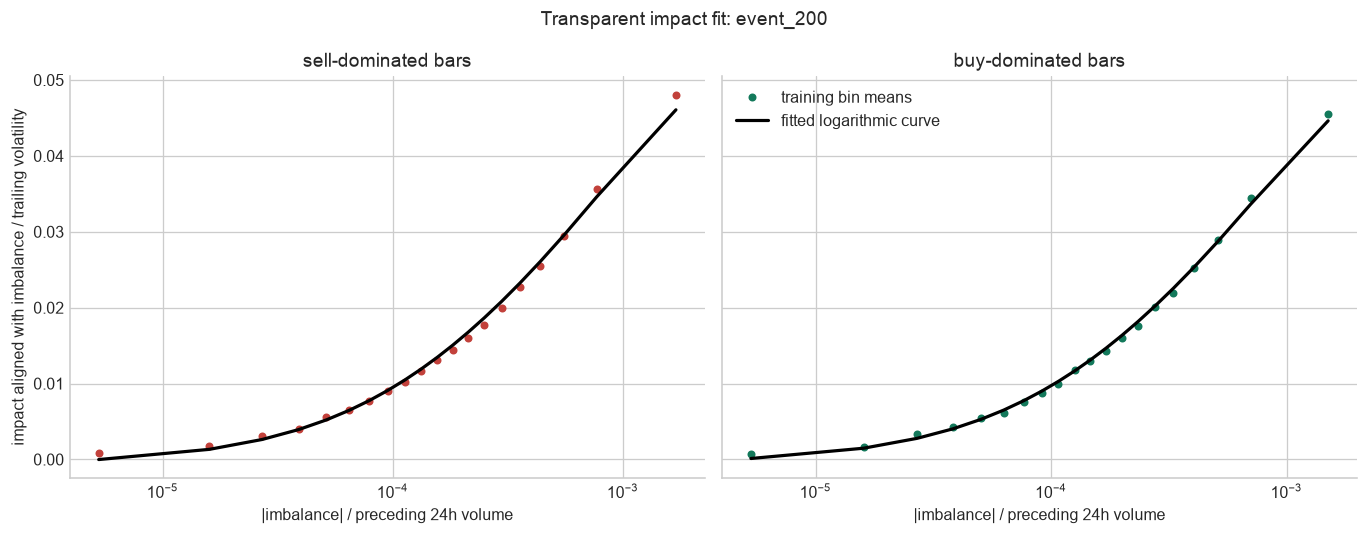

In [4]:
selected_fits = impact_fits.filter(pl.col('construction') == f'event_{BAR_SIZE}')
display(selected_fits)
for row in selected_fits.iter_rows(named=True):
    display(Markdown(
        f"**{row['side'].title()} equation:** "
        rf"$\widehat I={row['intercept']:.5f}+{row['slope']:.5f}"
        rf"\log(1+x/{row['imbalance_scale']:.3g})$; "
        f"training $R^2={row['r_squared']:.3f}$."
    ))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), sharey=True)
for ax, side_name, colour in zip(axes, ['sell', 'buy'], [SELL, BUY]):
    part = impact_bins.filter(
        (pl.col('construction') == f'event_{BAR_SIZE}') &
        (pl.col('side') == side_name)
    ).sort('mean_normalised_imbalance')
    ax.plot(part['mean_normalised_imbalance'], part['mean_observed_impact'],
            'o', ms=4, color=colour, label='training bin means')
    ax.plot(part['mean_normalised_imbalance'], part['mean_fitted_impact'],
            '-', lw=2, color='black', label='fitted logarithmic curve')
    ax.set_xscale('log')
    ax.set_xlabel('|imbalance| / preceding 24h volume')
    ax.set_title(f'{side_name}-dominated bars')
axes[0].set_ylabel('impact aligned with imbalance / trailing volatility')
axes[1].legend()
fig.suptitle(f'Transparent impact fit: event_{BAR_SIZE}')
plt.tight_layout()
plt.show()

## The frozen residual drifts through calendar time

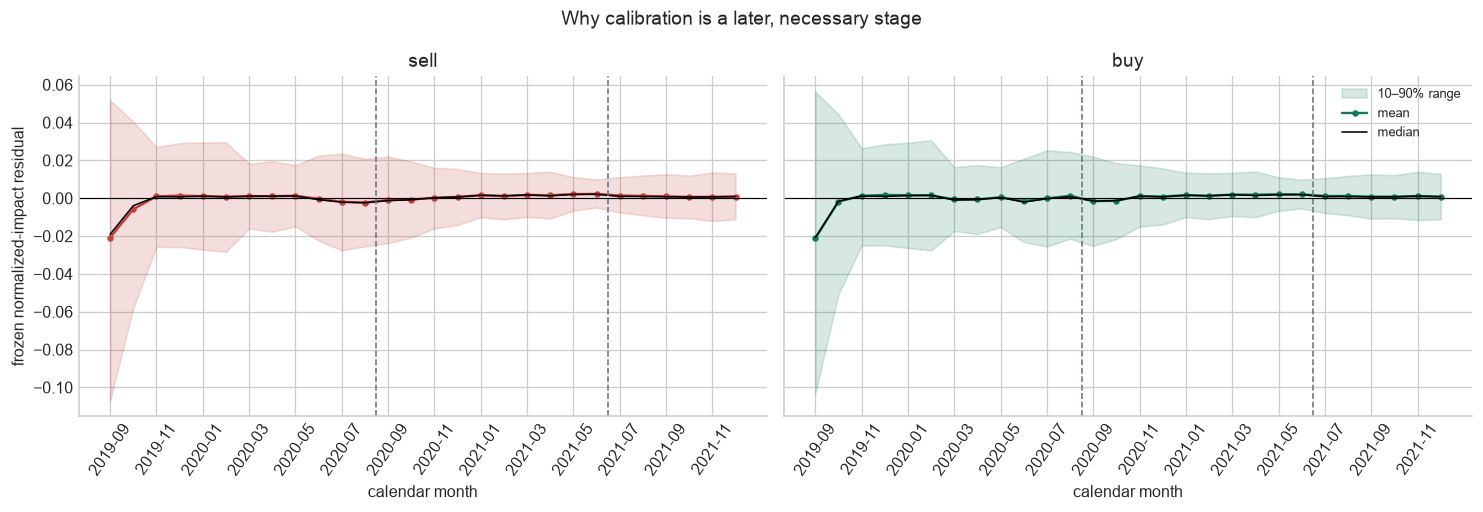

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, side_name, colour in zip(axes, ['sell', 'buy'], [SELL, BUY]):
    part = residual_monthly.filter(
        (pl.col('construction') == f'event_{BAR_SIZE}') &
        (pl.col('side') == side_name)
    ).sort('month')
    x = np.arange(part.height)
    ax.fill_between(x, part['residual_p10'], part['residual_p90'], color=colour, alpha=.17,
                    label='10–90% range')
    ax.plot(x, part['mean_residual'], color=colour, marker='o', ms=3, label='mean')
    ax.plot(x, part['median_residual'], color='black', lw=1, label='median')
    labels = part['month'].to_list()
    for split in ['2020-09', '2021-07']:
        if split in labels:
            ax.axvline(labels.index(split) - .5, color='#64748b', ls='--', lw=1)
    ax.axhline(0, color='black', lw=.7)
    ax.set_xticks(x[::2], labels[::2], rotation=55)
    ax.set_title(side_name)
    ax.set_xlabel('calendar month')
axes[0].set_ylabel('frozen normalized-impact residual')
axes[1].legend(fontsize=8)
fig.suptitle('Why calibration is a later, necessary stage')
plt.tight_layout()
plt.show()

## Step 1: simple reversion benchmarks

construction,horizon_minutes,period,side,strategy,signal_rate,day_mean_bps,day_t_stat,validation_fdr_q_value
str,i64,str,str,str,f64,f64,f64,f64
"""event_1000""",10,"""later_sandbox""","""all""","""prior_return_contrarian_q5""",0.026126,5.348677,3.01924,NaN
"""event_1000""",10,"""later_sandbox""","""buy""","""aligned_pretrend_q5_conditione…",0.005765,-1.418414,-0.471286,NaN
"""event_1000""",10,"""later_sandbox""","""buy""","""aligned_pretrend_reversion_q5""",0.065013,2.768861,2.373415,NaN
"""event_1000""",10,"""later_sandbox""","""sell""","""aligned_pretrend_q5_conditione…",0.006423,12.709212,3.647419,NaN
"""event_1000""",10,"""later_sandbox""","""sell""","""aligned_pretrend_reversion_q5""",0.068489,9.657598,7.894542,NaN
…,…,…,…,…,…,…,…,…
"""event_500""",15,"""validation""","""all""","""prior_return_contrarian_q5""",0.110592,5.944028,6.077138,2.7333e-9
"""event_500""",15,"""validation""","""buy""","""aligned_pretrend_q5_conditione…",0.012532,2.576052,1.314885,0.202016
"""event_500""",15,"""validation""","""buy""","""aligned_pretrend_reversion_q5""",0.157683,1.43987,1.629952,0.116416


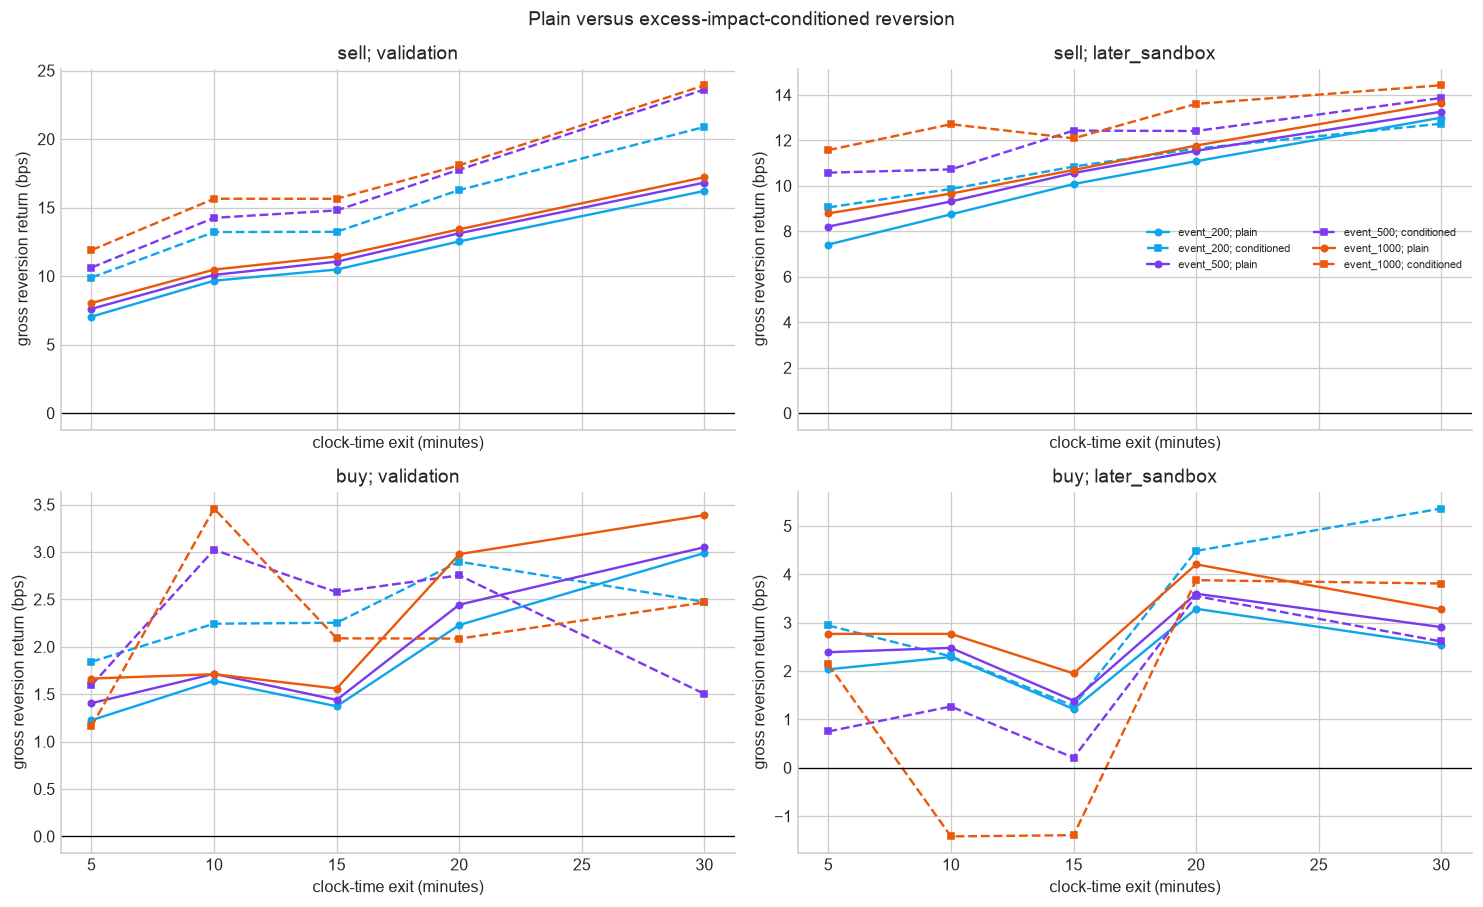

In [6]:
strategies = [
    'prior_return_contrarian_q5',
    'aligned_pretrend_reversion_q5',
    'aligned_pretrend_q5_conditioned_excess_q5',
]
display(signal_summary.filter(
    pl.col('horizon_minutes').is_in([10, 15]) &
    pl.col('strategy').is_in(strategies)
).select('construction', 'horizon_minutes', 'period', 'side', 'strategy',
         'signal_rate', 'day_mean_bps', 'day_t_stat', 'validation_fdr_q_value')
.sort(['period', 'horizon_minutes', 'construction', 'side', 'strategy']))

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for row_index, side_name in enumerate(['sell', 'buy']):
    for column_index, period in enumerate(['validation', 'later_sandbox']):
        ax = axes[row_index, column_index]
        for construction, colour in zip(['event_200', 'event_500', 'event_1000'],
                                        ['#0ea5e9', '#7c3aed', '#ea580c']):
            for strategy, linestyle, marker in [
                ('aligned_pretrend_reversion_q5', '-', 'o'),
                ('aligned_pretrend_q5_conditioned_excess_q5', '--', 's'),
            ]:
                part = signal_summary.filter(
                    (pl.col('construction') == construction) &
                    (pl.col('period') == period) &
                    (pl.col('side') == side_name) &
                    (pl.col('strategy') == strategy)
                ).sort('horizon_minutes')
                ax.plot(part['horizon_minutes'], part['day_mean_bps'], color=colour,
                        ls=linestyle, marker=marker, ms=4,
                        label=f"{construction}; {'conditioned' if 'conditioned' in strategy else 'plain'}")
        ax.axhline(0, color='black', lw=.8)
        ax.set_title(f'{side_name}; {period}')
        ax.set_xlabel('clock-time exit (minutes)')
        ax.set_ylabel('gross reversion return (bps)')
axes[0, 1].legend(fontsize=7, ncol=2)
fig.suptitle('Plain versus excess-impact-conditioned reversion')
plt.tight_layout()
plt.show()

The figures are conditional future returns, not realizable portfolio returns. Many signals overlap, and trading costs have not been deducted.

## Step 2: two-dimensional conditioning surface

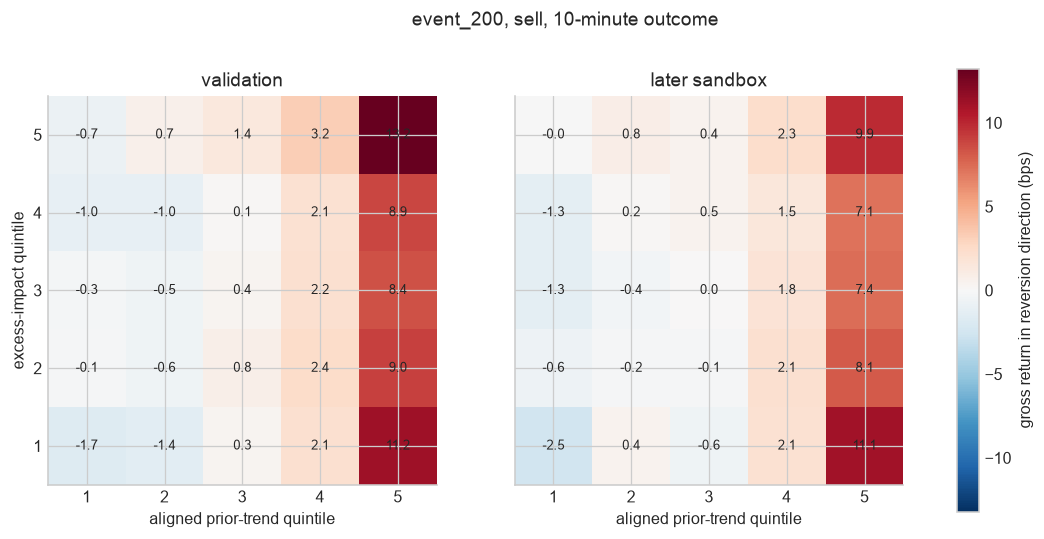

In [7]:
selected_grid = conditioning_grid.filter(
    (pl.col('construction') == f'event_{BAR_SIZE}') &
    (pl.col('horizon_minutes') == HORIZON_MINUTES) &
    (pl.col('side') == SIDE)
)
matrices = []
for period in ['validation', 'later_sandbox']:
    part = selected_grid.filter(pl.col('period') == period)
    matrix = np.full((5, 5), np.nan)
    for row in part.iter_rows(named=True):
        # Reverse sign so positive colours mean a profitable reversion direction.
        matrix[row['excess_impact_quintile'] - 1, row['pretrend_quintile'] - 1] = -row['day_mean_bps']
    matrices.append(matrix)
limit = max(float(np.nanmax(np.abs(matrix))) for matrix in matrices)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, period, matrix in zip(axes, ['validation', 'later sandbox'], matrices):
    image = ax.imshow(matrix, origin='lower', cmap='RdBu_r', vmin=-limit, vmax=limit)
    for y in range(5):
        for x in range(5):
            ax.text(x, y, f'{matrix[y, x]:.1f}', ha='center', va='center', fontsize=8)
    ax.set_title(period)
    ax.set_xlabel('aligned prior-trend quintile')
    ax.set_xticks(range(5), range(1, 6))
    ax.set_yticks(range(5), range(1, 6))
axes[0].set_ylabel('excess-impact quintile')
fig.colorbar(image, ax=axes, label='gross return in reversion direction (bps)')
fig.suptitle(f'event_{BAR_SIZE}, {SIDE}, {HORIZON_MINUTES}-minute outcome')
plt.show()

## Incremental value of the excess-impact filter

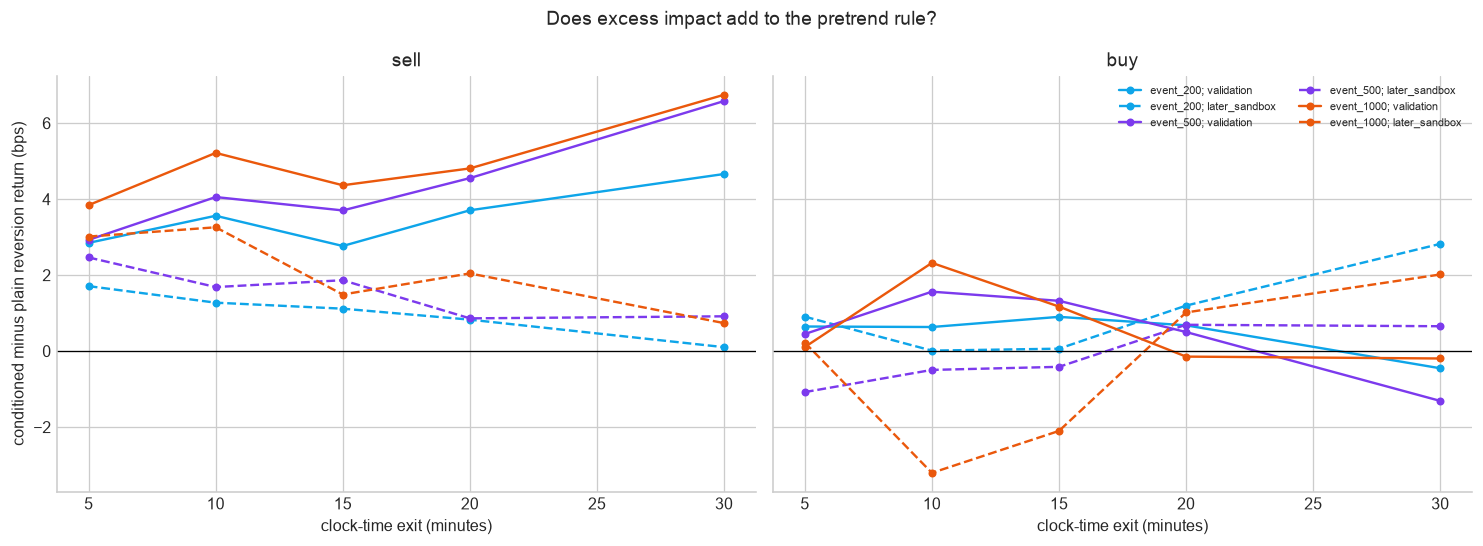

In [8]:
comparison = incremental.filter(
    pl.col('comparison') == 'high_excess_q5_minus_unconditioned'
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, side_name in zip(axes, ['sell', 'buy']):
    for construction, colour in zip(['event_200', 'event_500', 'event_1000'],
                                    ['#0ea5e9', '#7c3aed', '#ea580c']):
        for period, linestyle in [('validation', '-'), ('later_sandbox', '--')]:
            part = comparison.filter(
                (pl.col('construction') == construction) &
                (pl.col('side') == side_name) &
                (pl.col('period') == period)
            ).sort('horizon_minutes')
            ax.plot(part['horizon_minutes'], part['day_mean_difference_bps'],
                    color=colour, ls=linestyle, marker='o', ms=4,
                    label=f'{construction}; {period}')
    ax.axhline(0, color='black', lw=.8)
    ax.set_xlabel('clock-time exit (minutes)')
    ax.set_title(side_name)
axes[0].set_ylabel('conditioned minus plain reversion return (bps)')
axes[1].legend(fontsize=7, ncol=2)
fig.suptitle('Does excess impact add to the pretrend rule?')
plt.tight_layout()
plt.show()

## Monthly stability of the selected rule

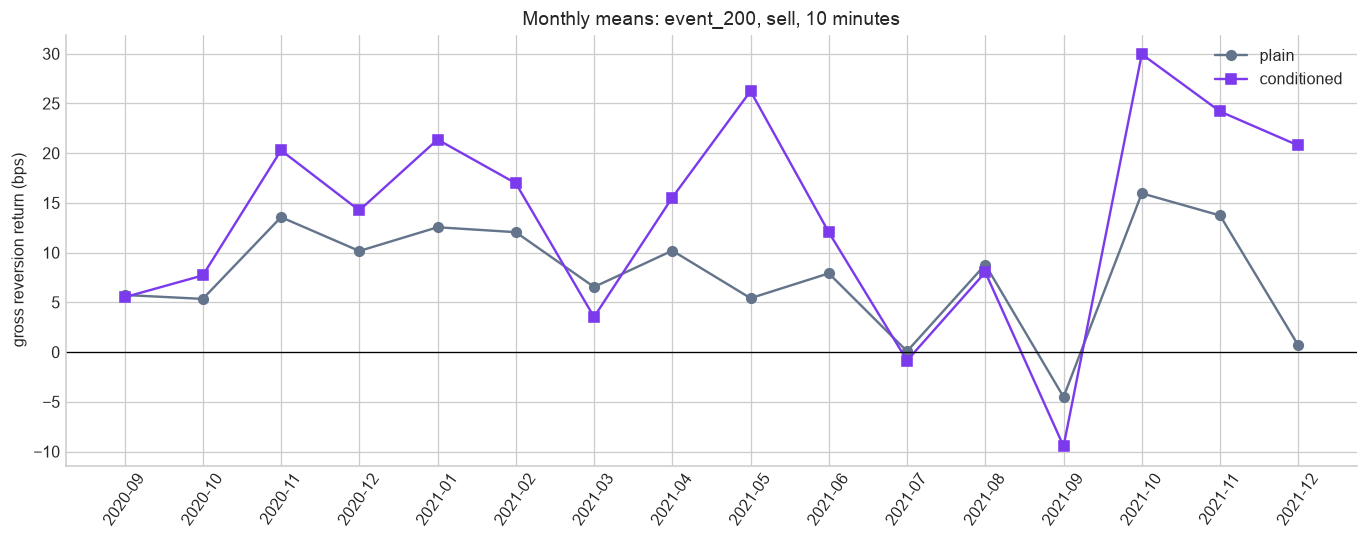

In [9]:
chosen_monthly = monthly_signal.filter(
    (pl.col('construction') == f'event_{BAR_SIZE}') &
    (pl.col('horizon_minutes') == HORIZON_MINUTES) &
    (pl.col('side') == SIDE) &
    pl.col('strategy').is_in([
        'aligned_pretrend_reversion_q5',
        'aligned_pretrend_q5_conditioned_excess_q5',
    ])
).sort('month')
fig, ax = plt.subplots(figsize=(12, 4.8))
for strategy, colour, marker in [
    ('aligned_pretrend_reversion_q5', '#64748b', 'o'),
    ('aligned_pretrend_q5_conditioned_excess_q5', '#7c3aed', 's'),
]:
    part = chosen_monthly.filter(pl.col('strategy') == strategy)
    ax.plot(part['month'].to_list(), part['mean_return_bps'], marker=marker,
            color=colour, label=('conditioned' if 'conditioned' in strategy else 'plain'))
ax.axhline(0, color='black', lw=.8)
ax.tick_params(axis='x', rotation=55)
ax.set_ylabel('gross reversion return (bps)')
ax.set_title(f'Monthly means: event_{BAR_SIZE}, {SIDE}, {HORIZON_MINUTES} minutes')
ax.legend()
plt.tight_layout()
plt.show()

# Detailed event-level decay

The decay sample selects events deterministically from the corrected event stream. Each selected event is classified using information available in the reconstructed schema:

- **single fill, single price**: one original fill at one execution price;
- **multiple fills, single price**: several fills but no price-level sweep;
- **multi-price**: executions at two or more distinct prices, further divided into 2, 3–4, 5–9, and 10+ levels.

For event side (s), previous-event price (P^-), first execution (P^f), last execution (P^l), and subsequent price (P_h):

\[
\text{entry}=s\log(P^f/P^-),\quad
\text{execution path}=s\log(P^l/P^f),
\]

\[
\text{immediate}=s\log(P^l/P^-),\quad
\text{total}(h)=s\log(P_h/P^-),\quad
\text{post}(h)=s\log(P_h/P^l).
\]

All displayed values below are in basis points. These are transaction-price responses, not quote-midpoint impulse responses.

## Exact event-class frequencies

In [10]:
counts = (category_counts.group_by('category').agg(
    pl.col('events').sum(),
    pl.col('total_quantity').sum(),
).with_columns(
    (pl.col('events') / pl.col('events').sum()).alias('event_share'),
    (pl.col('total_quantity') / pl.col('total_quantity').sum()).alias('quantity_share'),
).sort('events', descending=True))
display(counts)

category,events,total_quantity,event_share,quantity_share
str,i64,f64,f64,f64
"""single_fill_single_price""",456052237,5.0204e7,0.656428,0.19635
"""multi_fill_single_price""",99009389,3.8814e7,0.142511,0.151801
"""multi_price_2""",60532851,2.2872e7,0.087129,0.089454
"""multi_price_3_4""",42330584,2.7893e7,0.060929,0.109089
"""multi_price_5_9""",24995634,3.5409e7,0.035978,0.138486
"""multi_price_10_plus""",11827741,8.0495e7,0.017024,0.314819


## Raw buy and sell trajectories

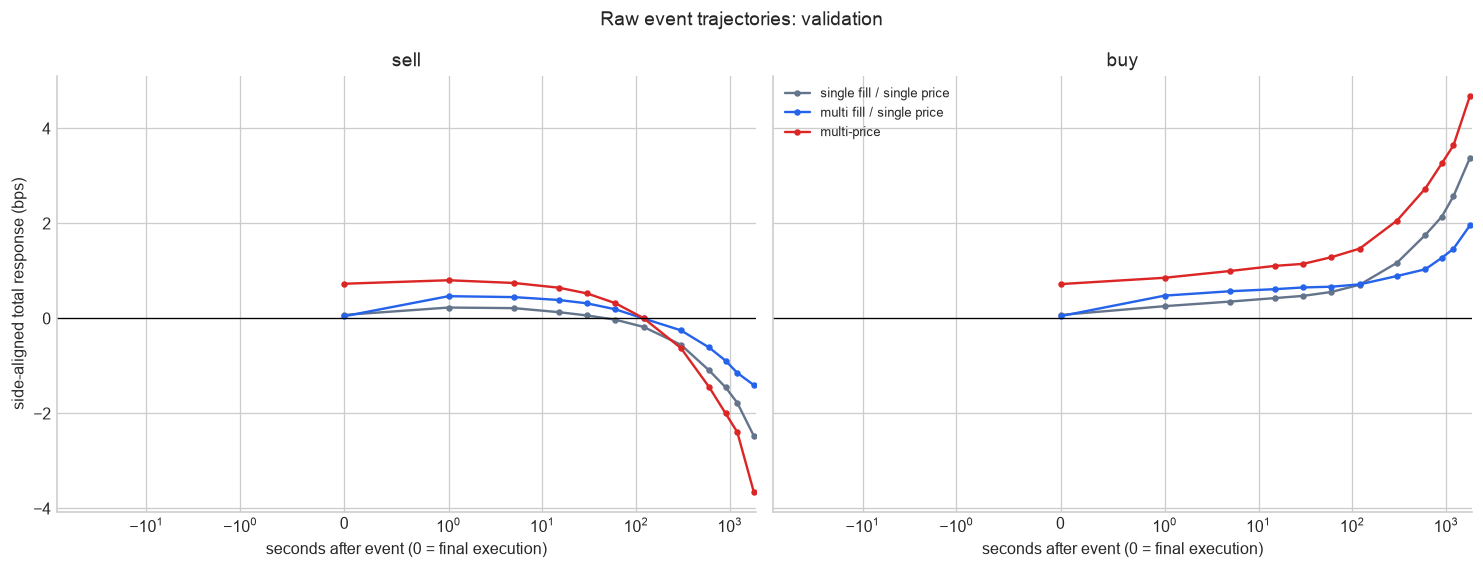

In [11]:
curve = decay_daily.group_by('period', 'category', 'side', 'horizon_seconds').agg(
    pl.len().alias('days'),
    pl.col('mean_immediate_response_bps').mean().alias('immediate'),
    pl.col('mean_total_response_bps').mean().alias('total'),
    pl.col('mean_post_event_response_bps').mean().alias('post'),
    pl.col('mean_execution_path_bps').mean().alias('execution_path'),
    (pl.col('mean_total_response_bps').std() / pl.len().sqrt()).alias('total_se'),
)

categories = ['single_fill_single_price', 'multi_fill_single_price', 'multi_price_all']
labels = ['single fill / single price', 'multi fill / single price', 'multi-price']
colours = ['#64748b', '#2563eb', '#dc2626']
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, side_name in zip(axes, ['sell', 'buy']):
    for category, label, colour in zip(categories, labels, colours):
        part = curve.filter(
            (pl.col('period') == DECAY_PERIOD) &
            (pl.col('side') == side_name) &
            (pl.col('category') == category)
        ).sort('horizon_seconds')
        x = np.r_[0, part['horizon_seconds'].to_numpy()]
        y = np.r_[part['immediate'][0], part['total'].to_numpy()]
        ax.plot(x, y, marker='o', ms=3, color=colour, label=label)
    ax.axhline(0, color='black', lw=.8)
    ax.set_xscale('symlog', linthresh=1)
    ax.set_xlabel('seconds after event (0 = final execution)')
    ax.set_title(side_name)
axes[0].set_ylabel('side-aligned total response (bps)')
axes[1].legend(fontsize=8)
fig.suptitle(f'Raw event trajectories: {DECAY_PERIOD}')
plt.tight_layout()
plt.show()

Raw buy and sell paths may contain common Bitcoin drift. To focus more closely on response associated with transaction direction, the next plot first averages buy- and sell-aligned daily responses with equal weight. This is a diagnostic, not a complete matched counterfactual.

## Equal-side decay by sweep depth

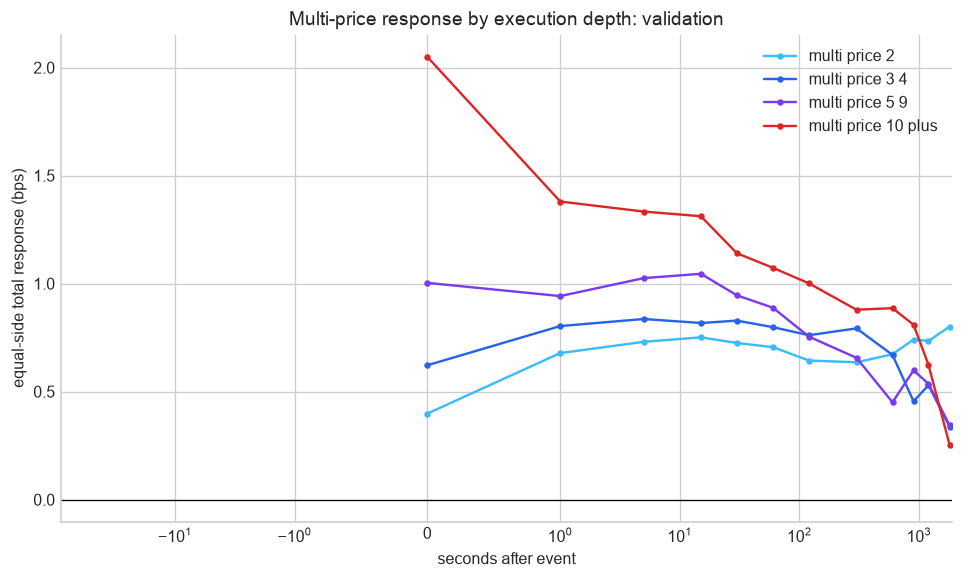

In [12]:
buy_daily = decay_daily.filter(pl.col('side') == 'buy').select(
    'period', 'category', 'utc_day', 'horizon_seconds',
    pl.col('mean_total_response_bps').alias('buy_total'),
    pl.col('mean_immediate_response_bps').alias('buy_immediate'),
)
sell_daily = decay_daily.filter(pl.col('side') == 'sell').select(
    'period', 'category', 'utc_day', 'horizon_seconds',
    pl.col('mean_total_response_bps').alias('sell_total'),
    pl.col('mean_immediate_response_bps').alias('sell_immediate'),
)
paired_daily = buy_daily.join(
    sell_daily, on=['period', 'category', 'utc_day', 'horizon_seconds'], how='inner'
).with_columns(
    ((pl.col('buy_total') + pl.col('sell_total')) / 2).alias('symmetric_total'),
    ((pl.col('buy_immediate') + pl.col('sell_immediate')) / 2).alias('symmetric_immediate'),
)
symmetric_curve = paired_daily.group_by('period', 'category', 'horizon_seconds').agg(
    pl.len().alias('paired_days'),
    pl.col('symmetric_total').mean().alias('total'),
    pl.col('symmetric_immediate').mean().alias('immediate'),
    (pl.col('symmetric_total').std() / pl.len().sqrt()).alias('standard_error'),
)

depth_categories = ['multi_price_2', 'multi_price_3_4', 'multi_price_5_9', 'multi_price_10_plus']
fig, ax = plt.subplots(figsize=(10, 5.5))
for category, colour in zip(depth_categories, ['#38bdf8', '#2563eb', '#7c3aed', '#dc2626']):
    part = symmetric_curve.filter(
        (pl.col('period') == DECAY_PERIOD) & (pl.col('category') == category)
    ).sort('horizon_seconds')
    x = np.r_[0, part['horizon_seconds'].to_numpy()]
    y = np.r_[part['immediate'][0], part['total'].to_numpy()]
    ax.plot(x, y, marker='o', ms=3, label=category.replace('_', ' '), color=colour)
ax.axhline(0, color='black', lw=.8)
ax.set_xscale('symlog', linthresh=1)
ax.set_xlabel('seconds after event')
ax.set_ylabel('equal-side total response (bps)')
ax.set_title(f'Multi-price response by execution depth: {DECAY_PERIOD}')
ax.legend()
plt.show()

## Incremental reaction and counterreaction

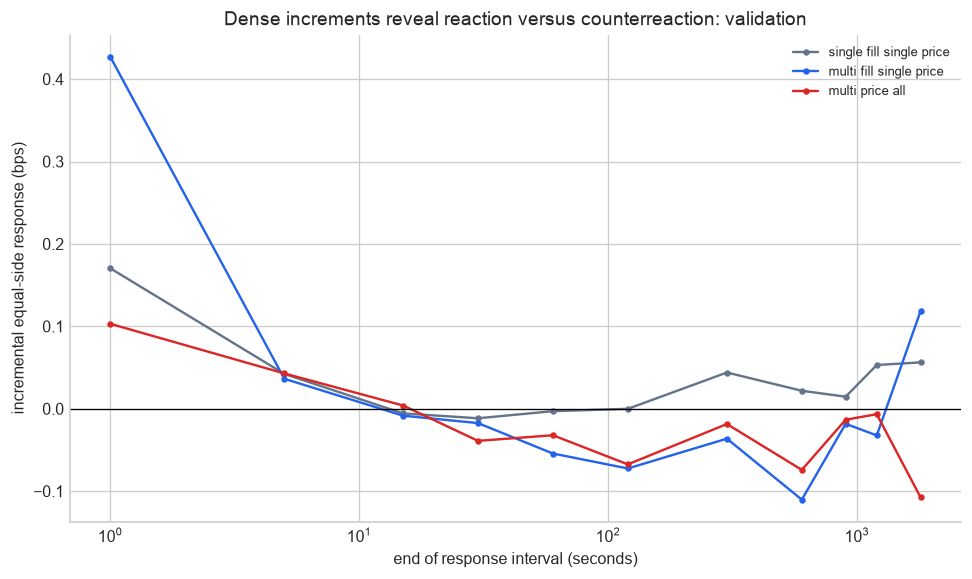

In [13]:
base = paired_daily.select(
    'period', 'category', 'utc_day',
    pl.lit(0, dtype=pl.Int64).alias('horizon_seconds'),
    pl.col('symmetric_immediate').alias('symmetric_total'),
)
path_daily = pl.concat([
    base,
    paired_daily.select('period', 'category', 'utc_day', 'horizon_seconds', 'symmetric_total')
]).sort('period', 'category', 'utc_day', 'horizon_seconds').with_columns(
    pl.col('symmetric_total').diff().over('period', 'category', 'utc_day').alias('increment')
)
increment_curve = path_daily.filter(pl.col('horizon_seconds') > 0).group_by(
    'period', 'category', 'horizon_seconds'
).agg(
    pl.col('increment').mean().alias('mean_increment'),
    (pl.col('increment').std() / pl.len().sqrt()).alias('standard_error'),
    pl.len().alias('paired_days'),
)

fig, ax = plt.subplots(figsize=(10, 5.5))
for category, colour in zip(
    ['single_fill_single_price', 'multi_fill_single_price', 'multi_price_all'],
    ['#64748b', '#2563eb', '#dc2626'],
):
    part = increment_curve.filter(
        (pl.col('period') == DECAY_PERIOD) & (pl.col('category') == category)
    ).sort('horizon_seconds')
    ax.plot(part['horizon_seconds'], part['mean_increment'], marker='o', ms=3,
            color=colour, label=category.replace('_', ' '))
ax.axhline(0, color='black', lw=.8)
ax.set_xscale('log')
ax.set_xlabel('end of response interval (seconds)')
ax.set_ylabel('incremental equal-side response (bps)')
ax.set_title(f'Dense increments reveal reaction versus counterreaction: {DECAY_PERIOD}')
ax.legend(fontsize=8)
plt.show()

## Immediate response decomposition

category,entry_displacement,execution_path,immediate
str,f64,f64,f64
"""multi_fill_single_price""",0.046658,0.0,0.046658
"""single_fill_single_price""",0.072594,0.0,0.072594
"""multi_price_2""",0.13476,0.263881,0.398642
"""multi_price_3_4""",0.13061,0.491532,0.622142
"""multi_price_5_9""",0.13671,0.866229,1.002939
"""multi_price_10_plus""",0.178879,1.870126,2.049005


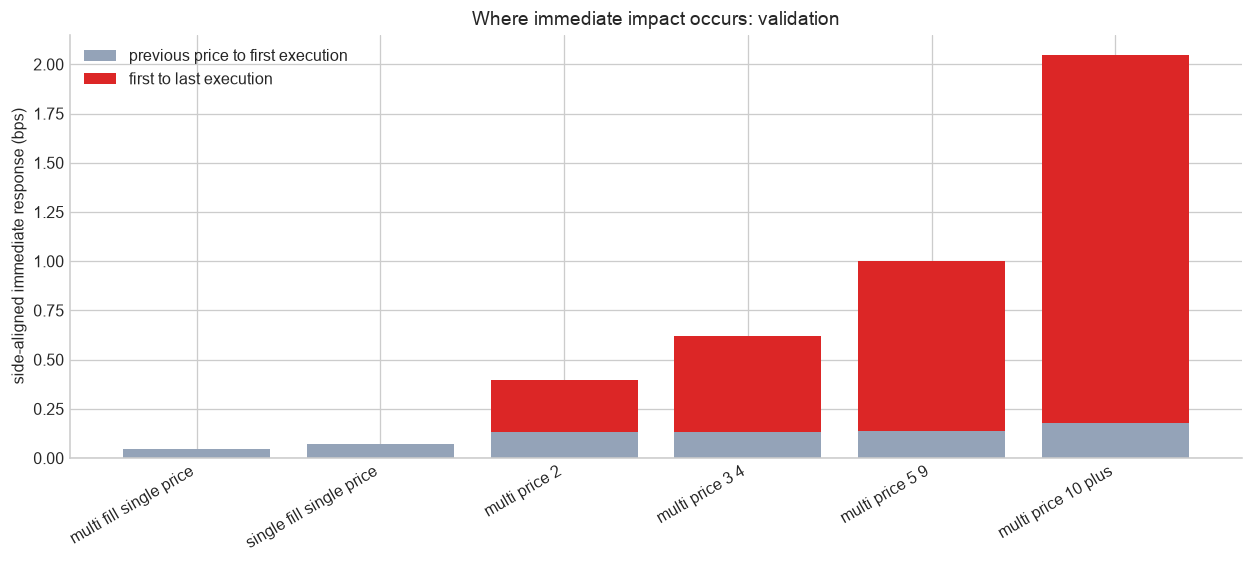

In [14]:
components = decay_daily.filter(
    (pl.col('period') == DECAY_PERIOD) &
    (pl.col('horizon_seconds') == 1) &
    pl.col('category').is_in([
        'single_fill_single_price', 'multi_fill_single_price',
        'multi_price_2', 'multi_price_3_4', 'multi_price_5_9', 'multi_price_10_plus'
    ])
).group_by('category').agg(
    pl.col('mean_entry_displacement_bps').mean().alias('entry_displacement'),
    pl.col('mean_execution_path_bps').mean().alias('execution_path'),
    pl.col('mean_immediate_response_bps').mean().alias('immediate'),
).sort('immediate')
display(components)

labels = [value.replace('_', ' ') for value in components['category']]
x = np.arange(components.height)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x, components['entry_displacement'], label='previous price to first execution', color='#94a3b8')
ax.bar(x, components['execution_path'], bottom=components['entry_displacement'],
       label='first to last execution', color='#dc2626')
ax.set_xticks(x, labels, rotation=30, ha='right')
ax.set_ylabel('side-aligned immediate response (bps)')
ax.set_title(f'Where immediate impact occurs: {DECAY_PERIOD}')
ax.legend()
plt.tight_layout()
plt.show()

## Initial reading and next decision

- The simple trailing-return contrarian benchmark is positive across the current 10–15 minute sandbox comparisons.
- Current-flow alignment identifies a much stronger sell-side reversion subset than buy-side subset.
- High excess impact raises sell-side conditional reversion in validation across all three event-bar sizes. The later sandbox retains a positive but smaller and statistically weaker increment.
- Buy-side conditioning is not stable: it adds little in validation and is often harmful later.
- Consequently, excess impact has **some mileage as a sell-side conditioner**, but not yet as a symmetric universal rule.
- Multi-price events have a materially larger immediate response, with a substantial component occurring while execution crosses prices.
- The equal-side multi-price response rises very briefly and then decays. The average curve does not by itself establish a recurring wave or resonance; the incremental plot is the appropriate place to look for reproducible sign changes.
- The frozen residual distribution and signal frequency drift materially, so rolling calibration should be examined before any profitability claim.

The next research gate is to decide whether to retain a narrowly specified sell-side excess-impact condition. If retained, temporal scale-collapse and rolling calibration come next. If not, the same two-dimensional framework can be used to test a small preregistered set of alternative conditioners.